In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('report_Lisbon_FDR1.pg_matrix.csv')

In [2]:
 df.shape

(492, 84)

In [3]:
df

,Protein.Group,Protein.Names,Genes,First.Protein.Description,N.Sequences,N.Proteotypic.Sequences,C:\Manadas\share_PC_Manadas\DanielaAraujo\S01_LIS020_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S02_LIS054_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S03_LIS044_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S04_LIS053_10uLof30uL_SWATH.wiff.dia,...,C:\Manadas\share_PC_Manadas\DanielaAraujo\S67_LIS087_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S68_LIS088_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S69_LIS094_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S70_LIS096_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S71_LIS097_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S72_LIS102_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S73_LIS103_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S74_LIS104_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S75_LIS116_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S76_LIS117_10uLof30uL_SWATH.wiff.dia
0,A0A075B6H7,KV37_HUMAN,IGKV3-7,Probable non-functional immunoglobulin kappa v...,2,1,2765.7200,1680.4800,7286.8700,3478.590,...,2225.7300,2324.000,1699.9000,5204.950,3062.5300,3934.2400,6397.0100,4505.5600,4620.9100,3298.9600
1,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,2,2,22.2270,87.9395,273.3420,NaN,...,27.9519,NaN,30.9206,100.591,49.8716,47.9074,127.1660,90.1098,17.0926,31.2933
2,A0A075B6J9,LV218_HUMAN,IGLV2-18,Immunoglobulin lambda variable 2-18,2,1,72.3171,37.3179,60.1143,104.516,...,42.1034,NaN,27.6053,NaN,39.6909,NaN,85.5746,37.5523,20.3119,35.9497
3,A0A075B6K5,LV39_HUMAN,IGLV3-9,Immunoglobulin lambda variable 3-9,2,1,203.0530,123.1380,398.9520,358.261,...,127.8960,113.068,51.2467,279.736,128.8590,96.3158,305.1740,129.2580,134.3460,65.5010
4,A0A075B6P5;P01615;A0A087WW87;P01614,KV228_HUMAN;KV240_HUMAN;KVD28_HUMAN;KVD40_HUMAN,IGKV2-28;IGKV2-40;IGKV2D-28;IGKV2D-40,Immunoglobulin kappa variable 2-28,1,0,1294.4100,344.9990,1882.5700,443.939,...,896.3350,398.447,460.9030,711.119,1378.9600,924.8090,1985.1500,534.0280,1205.1000,1386.6500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,Q9Y6R7,FCGBP_HUMAN,FCGBP,IgGFc-binding protein,33,33,377.4010,271.4500,913.5500,507.202,...,301.7030,566.379,337.6280,726.382,747.0370,758.3560,1125.8300,1297.8200,1385.2500,686.2130
488,cRAP-P00760,cRAP-TRY1_BOVIN,NaN,Cationic trypsin,5,5,233676.0000,211696.0000,337200.0000,307022.000,...,262902.0000,247006.000,270748.0000,293007.000,267243.0000,330518.0000,275874.0000,347417.0000,375463.0000,257574.0000
489,cRAP-P00761,cRAP-TRYP_PIG,NaN,Trypsin,2,2,341.3970,293.5920,410.1920,474.222,...,258.8920,455.180,493.1050,504.033,452.5590,377.1780,248.6950,292.8160,659.7700,439.6180
490,cRAP-P0AEY0,MALE_ECO57,malE,Maltose-binding periplasmic protein,34,34,127100.0000,148222.0000,194553.0000,203412.000,...,163146.0000,147432.000,123615.0000,131137.000,137872.0000,159853.0000,153611.0000,161232.0000,178222.0000,123324.0000


Refining Column Headers for Enhanced Sample Identification

Adjusting column metadata to improve the readability of patient identifiers (IDs) and ensure consistent data visualization.

In [4]:
import re

In [5]:
df.columns = [re.search(r"LIS\d+", col).group(0) if re.search(r"LIS\d+", col) else col for col in df.columns]

Assessment of Technical Replicate Correlation for Data Merging

To evaluate the reproducibility of the measurements, we calculate the correlation between technical replicates. High correlation coefficients justify the subsequent step of averaging the replicates into a single representative sample, thereby reducing noise and simplifying the dataset for downstream analysis.

In [6]:
df_LIS021 = df['LIS021']   # prende tutte le colonne chiamate LIS021

uno = df_LIS021.iloc[:, 0]
due = df_LIS021.iloc[:, 1]

correlazione = uno.corr(due)
print(correlazione)

0.930575654612811


In [7]:
df_LIS021 = df['LIS034']   # prende tutte le colonne chiamate LIS021

uno = df_LIS021.iloc[:, 0]
due = df_LIS021.iloc[:, 1]

correlazione = uno.corr(due)
print(correlazione)

0.9895212069805348


In [8]:
df_LIS021 = df['LIS023']   # prende tutte le colonne chiamate LIS021

uno = df_LIS021.iloc[:, 0]
due = df_LIS021.iloc[:, 1]

correlazione = uno.corr(due)
print(correlazione)

0.9284743321880953


Data Restructuring: Transposition and Feature Selection

The protein expression matrix was transposed to align with standard statistical analysis formats, placing individual patients in rows and protein identifiers in columns. During this process, non-quantitative columns (metadata not representing protein intensities) were removed to ensure the dataset exclusively contains numerical expression values for downstream processing.

In [9]:
df_indexed = df.set_index('Protein.Group')

In [10]:
df_numeric = df_indexed.iloc[:, 5:]

In [11]:
df_matrix_T = df_numeric.T

In [12]:
df_matrix_T

Protein.Group,A0A075B6H7,A0A075B6I0,A0A075B6J9,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6R2,A0A075B6R9;A0A0C4DH68,A0A075B6S2;A0A0A0MRZ7;A2NJV5,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A075B6S9;P0DSN7,...,Q9Y4C0,Q9Y5I4,Q9Y5Y7,Q9Y646,Q9Y6N7,Q9Y6R7,cRAP-P00760,cRAP-P00761,cRAP-P0AEY0,cRAP-P42212
LIS020,2765.72,22.2270,72.3171,203.0530,1294.410,53.0718,785.713,NaN,490.172,NaN,...,475.813,51.8003,60.9571,134.6900,29.8334,377.401,233676.0,341.397,127100.0,188114.0
LIS054,1680.48,87.9395,37.3179,123.1380,344.999,NaN,172.665,248.480,145.149,NaN,...,389.625,26.8569,62.1100,99.1111,24.4571,271.450,211696.0,293.592,148222.0,256793.0
LIS044,7286.87,273.3420,60.1143,398.9520,1882.570,104.9320,1061.150,486.796,895.897,NaN,...,298.168,NaN,88.7272,120.6860,NaN,913.550,337200.0,410.192,194553.0,362921.0
LIS053,3478.59,NaN,104.5160,358.2610,443.939,61.1363,1264.190,NaN,671.084,38.2504,...,341.211,34.7535,67.9932,126.8680,19.7543,507.202,307022.0,474.222,203412.0,382877.0
LIS090,2765.08,54.8819,NaN,128.7230,486.692,NaN,225.964,NaN,316.766,NaN,...,422.239,32.7511,50.5493,86.1335,27.3094,870.229,285967.0,441.323,185203.0,322818.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS102,3934.24,47.9074,NaN,96.3158,924.809,NaN,410.324,290.006,293.059,NaN,...,551.343,23.1060,85.7320,103.7710,28.2173,758.356,330518.0,377.178,159853.0,309709.0
LIS103,6397.01,127.1660,85.5746,305.1740,1985.150,NaN,424.258,391.723,803.771,NaN,...,302.717,13.9528,54.1178,80.2208,23.0786,1125.830,275874.0,248.695,153611.0,286728.0
LIS104,4505.56,90.1098,37.5523,129.2580,534.028,NaN,420.686,NaN,427.967,NaN,...,255.098,NaN,56.8257,87.0760,NaN,1297.820,347417.0,292.816,161232.0,301612.0
LIS116,4620.91,17.0926,20.3119,134.3460,1205.100,NaN,466.842,NaN,551.367,NaN,...,167.741,NaN,52.7447,112.2890,21.9518,1385.250,375463.0,659.770,178222.0,360208.0


Aggregation of Technical Replicates via Mean Calculation

To consolidate the dataset, columns representing technical replicates for the same patient were aggregated. We calculated the arithmetic mean of protein intensities across these replicates to generate a single, robust quantitative profile per subject, thereby reducing intra-sample variability

In [13]:
df_matrix_T = df_matrix_T.groupby(df_matrix_T.index).mean()

Quality Control: Assessment of Missing Values (NaN)

We performed a comprehensive screening of the dataset to quantify missing data (NaN values). The analysis was conducted at two levels: per-protein (column-wise) and per-patient (row-wise). Both absolute counts and percentage distributions were calculated to evaluate data completeness and identify potential outliers or low-quality features

In [14]:
list_prot_nan = df_matrix_T.isna().sum().tolist()

In [15]:
list_examples_nan = df_matrix_T.isna().sum(axis=1).tolist()

In [16]:
df_matrix_T.isna().sum().sum()

4982

In [17]:
perc_prot = []
n_patients = df_matrix_T.shape[0]
for i in list_prot_nan:
    res = (i/n_patients)*100
    perc_prot.append(res)

In [18]:
n_patients

75

In [19]:
perc_examples = []
n_proteins = df_matrix_T.shape[1]
for i in list_examples_nan:
    res_2 = (i/n_proteins)*100
    perc_examples.append(res_2)

In [20]:
n_proteins

492

In [21]:
perc_prot = pd.Series(perc_prot)
perc_prot.describe()

count    492.000000
mean      13.501355
std       22.650143
min        1.333333
25%        1.333333
50%        1.333333
75%       16.000000
max       98.666667
dtype: float64

In [22]:
perc_examples = pd.Series(perc_examples)
perc_examples.describe()

count     75.000000
mean      13.501355
std       10.792300
min        7.113821
25%        9.857724
50%       11.585366
75%       14.532520
max      100.000000
dtype: float64

In [23]:
import matplotlib.pyplot as plt

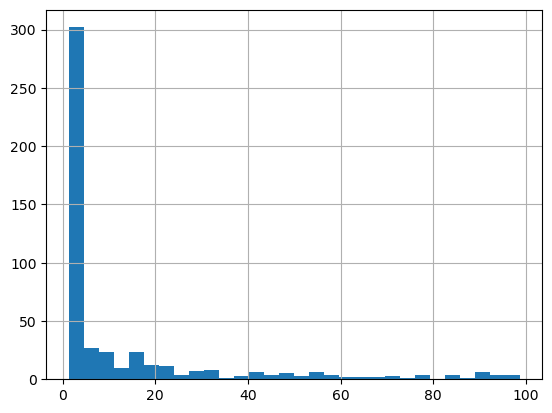

In [24]:
perc_prot.describe()
perc_prot.hist(bins=30)
plt.savefig('distribution_nan_proteins.png')

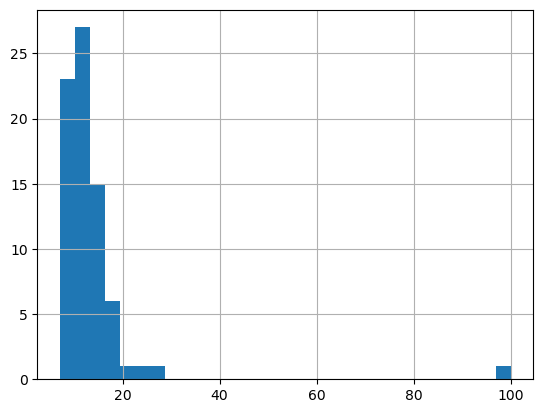

In [25]:
perc_examples.describe()
perc_examples.hist(bins=30)
plt.savefig('distribution_nan_examples.png')

In [26]:
(perc_prot > 50).sum()

46

In [27]:
(perc_prot > 70).sum()

27

In [28]:
perc_prot.sort_values(ascending=False)

196    98.666667
472    96.000000
310    96.000000
226    96.000000
337    94.666667
         ...    
195     1.333333
194     1.333333
193     1.333333
192     1.333333
491     1.333333
Length: 492, dtype: float64

In [29]:
perc_examples.sort_values(ascending=False)

48    100.000000
4      25.813008
72     24.390244
63     22.357724
23     18.902439
         ...    
24      7.723577
36      7.723577
56      7.520325
15      7.317073
21      7.113821
Length: 75, dtype: float64

Exploratory Data Analysis: Distribution and Correlation Profiling

To assess the overall data quality and consistency, we performed an Exploratory Data Analysis (EDA). A boxplot of protein intensities was generated for each sample to evaluate normalization and identify potential batch effects. Additionally, a Pearson correlation heatmap was constructed to visualize global similarities between patient profiles and ensure biological consistency

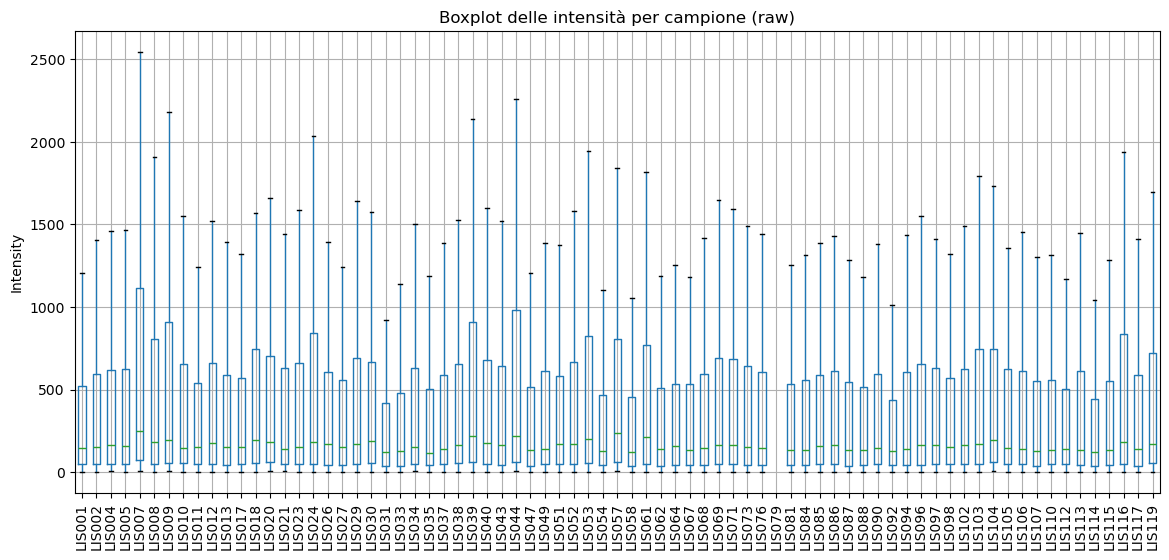

In [30]:
plt.figure(figsize=(14,6))
df_matrix_T.T.boxplot(showfliers=False)
plt.xticks(rotation=90)
plt.ylabel("Intensity")
plt.title("Boxplot delle intensità per campione (raw)")
dpi=300
plt.savefig('Boxplot_delle_intensità_per_campione.png')
plt.show()

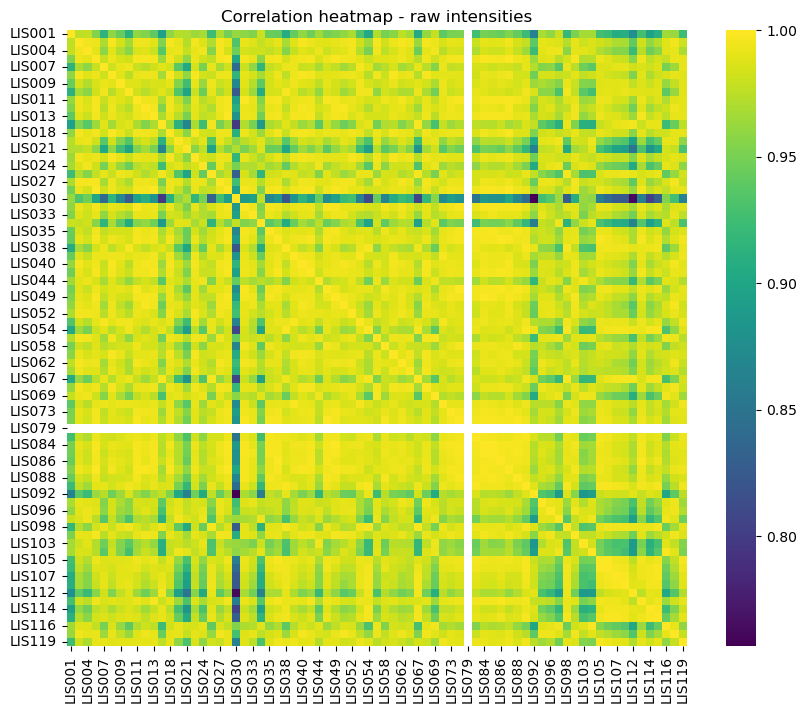

In [31]:
import seaborn as sns

# correlazione tra pazienti
corr_matrix = df_matrix_T.T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="viridis")
plt.title("Correlation heatmap - raw intensities")
dpi=300
plt.savefig('Correlation_heatmap.png')
plt.show()

Exclusion of Samples with Null Observations

Sample LIS079 was excluded from the dataset prior to further analysis. This decision was made because the sample showed a complete lack of protein identifications (zero intensity values across the entire profile), making it uninformative for statistical comparison.

In [32]:
perc_examples.sort_values()

21      7.113821
15      7.317073
56      7.520325
24      7.723577
36      7.723577
         ...    
23     18.902439
63     22.357724
72     24.390244
4      25.813008
48    100.000000
Length: 75, dtype: float64

In [33]:
df_without_patient = df_matrix_T.drop('LIS079')

In [34]:
list_examples_nan_2 = df_without_patient.isna().sum(axis=1).tolist()

In [35]:
perc_examples_2 = []
n_proteins_2 = df_without_patient.shape[1]
for i in list_examples_nan_2:
    res_3 = (i/n_proteins_2)*100
    perc_examples_2.append(res_3)

In [36]:
perc_examples_2 = pd.Series(perc_examples_2)
perc_examples_2.describe()

count    74.000000
mean     12.332454
std       3.767077
min       7.113821
25%       9.806911
50%      11.483740
75%      14.430894
max      25.813008
dtype: float64

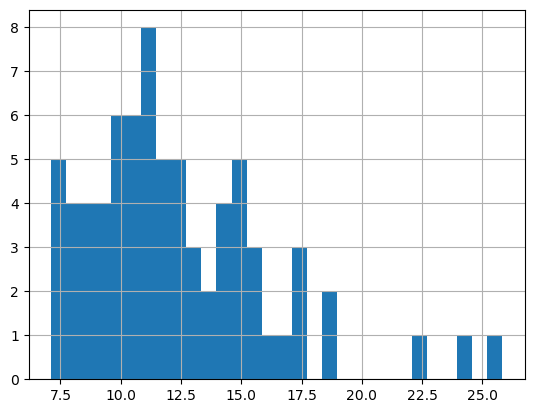

In [37]:
perc_examples_2.hist(bins=30)
plt.savefig('distribution_nan_examples_no_LIS079.png')

In [38]:
list_prot_nan_2 = df_without_patient.isna().sum().tolist()

In [39]:
perc_prot_2 = []
n_patients_2 = df_without_patient.shape[0]
for i in list_prot_nan_2:
    res = (i/n_patients_2)*100
    perc_prot_2.append(res)

In [40]:
n_patients_2

74

In [41]:
perc_prot_2 = pd.Series(perc_prot_2)
perc_prot_2.describe()

count    492.000000
mean      12.332454
std       22.956226
min        0.000000
25%        0.000000
50%        0.000000
75%       14.864865
max       98.648649
dtype: float64

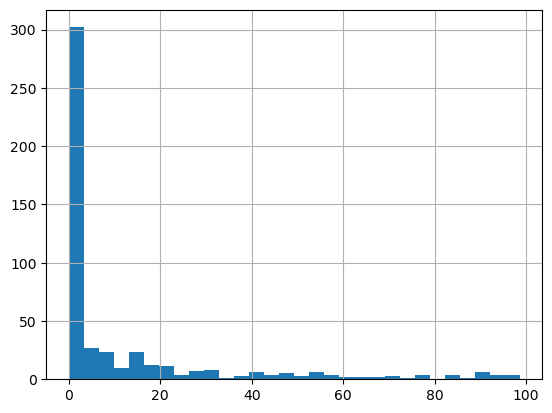

In [42]:
perc_prot_2.describe()
perc_prot_2.hist(bins=30)
plt.savefig('distribution_nan_proteins_no_LIS079.png')

Data Filtering Based on Missing Value Thresholds

To ensure the statistical power of the analysis, a filtering step was implemented based on the percentage of missing values (NaN). Features (proteins) and observations (patients) that exceeded a predefined threshold of missingness were excluded. This process refines the dataset, retaining only the most robust and informative variables for downstream statistical testing.

In [43]:
perc_prot_2.sort_values(ascending=False)

196    98.648649
472    95.945946
310    95.945946
226    95.945946
337    94.594595
         ...    
195     0.000000
194     0.000000
193     0.000000
192     0.000000
491     0.000000
Length: 492, dtype: float64

In [44]:
count = 0

for i in perc_prot_2.tolist():
    if i == 0:
        count += 1
print(count)

260


In [45]:
df_clean_Nan = df_without_patient.dropna(axis=1)

In [46]:
df_clean_Nan

Protein.Group,A0A075B6H7,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A075B7B8,A0A0A0MRZ8;P04433,A0A0A0MS15,A0A0B4J1U7,A0A0B4J1X5,A0A0B4J1Y9,...,Q9UGM5,Q9UHL4,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7,cRAP-P00760,cRAP-P00761,cRAP-P0AEY0,cRAP-P42212
LIS001,1107.69,164.4250,680.149,217.519,252.2630,735.020,342.379,540.817,144.628,380.645,...,72.6314,57.9925,288.4620,434.958,88.6221,197.755,105277.0,146.825,59104.9,133354.0
LIS002,3211.86,118.4420,632.426,326.820,332.4430,1131.700,204.096,1154.720,395.670,988.652,...,90.8588,68.6941,362.6710,444.882,85.7893,489.599,213246.0,298.711,134810.0,226701.0
LIS004,4100.20,87.2034,1030.680,259.841,183.6250,1754.910,188.676,345.993,384.503,992.745,...,40.8080,128.0000,389.9040,407.450,149.1840,484.826,198793.0,221.474,118845.0,198361.0
LIS005,2707.90,260.1930,759.890,296.240,649.3700,1466.800,395.963,1343.720,401.542,1319.600,...,74.4093,73.5323,336.9240,451.991,92.4364,407.396,209332.0,259.741,122407.0,203802.0
LIS007,6654.40,661.7690,1152.800,1376.850,739.3510,4405.340,1371.610,714.108,525.832,1941.660,...,220.0540,87.0254,76.8903,172.473,112.7740,600.054,453940.0,461.130,316405.0,614620.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS114,1500.83,68.3067,302.147,134.906,293.4280,657.856,404.861,416.617,262.033,449.175,...,32.7352,99.9600,370.5660,471.472,77.1212,113.220,229540.0,307.536,195353.0,278141.0
LIS115,1499.82,82.8375,521.264,222.505,84.9046,782.878,187.254,236.554,194.188,370.731,...,47.9753,120.2410,246.0000,335.982,128.0470,1285.770,318237.0,782.564,249495.0,377440.0
LIS116,4620.91,134.3460,1205.100,551.367,603.4230,2602.070,1721.090,767.140,526.479,1593.300,...,65.8156,61.4767,110.4220,167.741,112.2890,1385.250,375463.0,659.770,178222.0,360208.0
LIS117,3298.96,65.5010,1386.650,247.178,274.4990,1412.610,305.365,998.735,282.080,1124.220,...,57.2130,104.1630,325.9490,401.025,73.8704,686.213,257574.0,439.618,123324.0,239426.0


In [47]:
df_clean_Nan.isnull().sum().sum()

0

Protein Quality FilteringProteins identified with fewer than two proteotypic peptides ($N.proteotypic < 2$) were excluded to ensure high-confidence identification and reduce false positives.

In [48]:
df = df[df['N.Proteotypic.Sequences'] >= 2]

In [49]:
df['N.Proteotypic.Sequences'].sort_values()

1       2
424     2
199     2
156     2
153     2
       ..
96     51
142    53
150    61
148    74
97     95
Name: N.Proteotypic.Sequences, Length: 351, dtype: int64

In [50]:
df

,Protein.Group,Protein.Names,Genes,First.Protein.Description,N.Sequences,N.Proteotypic.Sequences,LIS020,LIS054,LIS044,LIS053,...,LIS087,LIS088,LIS094,LIS096,LIS097,LIS102,LIS103,LIS104,LIS116,LIS117
1,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,2,2,22.2270,87.9395,273.3420,NaN,...,27.9519,NaN,30.9206,100.5910,49.8716,47.9074,127.1660,90.1098,17.0926,31.2933
15,A0A0A0MS15,HV349_HUMAN,IGHV3-49,Immunoglobulin heavy variable 3-49,2,2,173.9880,323.0540,1077.8600,1051.5700,...,412.3130,181.5050,133.0200,492.7360,383.0870,383.5330,363.1470,457.7140,1721.0900,305.3650
18,A0A0B4J1V0,HV315_HUMAN,IGHV3-15,Immunoglobulin heavy variable 3-15,2,2,301.8290,149.8300,NaN,317.2510,...,154.0180,NaN,126.0500,NaN,NaN,178.1600,283.6140,190.5170,314.3970,190.3210
20,A0A0B4J1V2,HV226_HUMAN,IGHV2-26,Immunoglobulin heavy variable 2-26,2,2,37.5085,30.5498,96.0463,57.8244,...,25.2946,51.4402,27.9102,95.0737,107.7390,49.7495,175.4780,70.1951,48.0688,35.8822
30,A0A0C4DH33,HV124_HUMAN,IGHV1-24,Immunoglobulin heavy variable 1-24,2,2,NaN,10.9212,NaN,NaN,...,16.4985,NaN,NaN,18.6527,12.5278,14.5472,26.4981,NaN,NaN,19.7961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,Q9Y6R7,FCGBP_HUMAN,FCGBP,IgGFc-binding protein,33,33,377.4010,271.4500,913.5500,507.2020,...,301.7030,566.3790,337.6280,726.3820,747.0370,758.3560,1125.8300,1297.8200,1385.2500,686.2130
488,cRAP-P00760,cRAP-TRY1_BOVIN,NaN,Cationic trypsin,5,5,233676.0000,211696.0000,337200.0000,307022.0000,...,262902.0000,247006.0000,270748.0000,293007.0000,267243.0000,330518.0000,275874.0000,347417.0000,375463.0000,257574.0000
489,cRAP-P00761,cRAP-TRYP_PIG,NaN,Trypsin,2,2,341.3970,293.5920,410.1920,474.2220,...,258.8920,455.1800,493.1050,504.0330,452.5590,377.1780,248.6950,292.8160,659.7700,439.6180
490,cRAP-P0AEY0,MALE_ECO57,malE,Maltose-binding periplasmic protein,34,34,127100.0000,148222.0000,194553.0000,203412.0000,...,163146.0000,147432.0000,123615.0000,131137.0000,137872.0000,159853.0000,153611.0000,161232.0000,178222.0000,123324.0000


In [51]:
list_protein_original_matrix = df['Protein.Group'].tolist()

In [52]:
list_protein_modified_matrix = df_clean_Nan.columns.tolist()

In [53]:
final_list = []
for i in list_protein_modified_matrix:
    for j in list_protein_original_matrix:
        if i == j :
            final_list.append(i)
print(len(final_list))

234
